In [1]:
import env
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Callable, Tuple
from pathlib import Path
from models_config import arch, get_stage_configs
from sample_tensors import b64_to_tensor
from ds.cladder import load_cladder_v1_5, CLadderLoaderConfig, CLadderSample
from InProgressInstance import gather_instances, InProgressInstance

do_models = [
    "Qwen/Qwen3-4B",
    "meta-llama/Llama-3.2-3B-Instruct",
    "Qwen/Qwen3-8B",
    "meta-llama/Llama-3.1-8B-Instruct"
]
model_ablations = ["cadgn", "adgn", "gcn", "gat", "dec"]


In [2]:
## Load full dataset for comparison's purposes
dsConfig = CLadderLoaderConfig(rung_filter=None, query_types=None, skip_unparseable=True)

org_ds = load_cladder_v1_5(dsConfig)

## Load models (we need the EncoderHead specifically)
s1c, s2c, evals2c = get_stage_configs(40)
save_path = Path("./saves/ablations/")
save_path.mkdir(parents=True, exist_ok=True)

in_progress = gather_instances(
    s1config=s1c,
    arch_params=arch,
    ablations=model_ablations,
    llm_models=do_models,
    save_path=save_path,
    ip=True
)

Processing 10112 rows...
Loaded 8532 graphs, skipped 1580 unparseable rows.
Reloading from checkpoint for Stage 1 (ablation=cadgn(0), MMD Weight=0.0)


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

GPU: 0.00GB allocated / 0.00GB reserved


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

GPU: 0.00GB allocated / 0.00GB reserved


Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

GPU: 0.00GB allocated / 0.00GB reserved


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

GPU: 0.00GB allocated / 0.00GB reserved
	>> Complete!
Reloading from checkpoint for Stage 1 (ablation=cadgn(0), MMD Weight=1.0)
Moving Qwen/Qwen3-4B's embed_layer from cpu to cpu
GPU: 0.00GB allocated / 0.00GB reserved
Moving meta-llama/Llama-3.2-3B-Instruct's embed_layer from cpu to cpu
GPU: 0.00GB allocated / 0.00GB reserved
Moving Qwen/Qwen3-8B's embed_layer from cpu to cpu
GPU: 0.00GB allocated / 0.00GB reserved
Moving meta-llama/Llama-3.1-8B-Instruct's embed_layer from cpu to cpu
GPU: 0.00GB allocated / 0.00GB reserved
	>> Complete!
Reloading from checkpoint for Stage 1 (ablation=adgn(1), MMD Weight=0.0)
Moving Qwen/Qwen3-4B's embed_layer from cpu to cpu
GPU: 0.00GB allocated / 0.00GB reserved
Moving meta-llama/Llama-3.2-3B-Instruct's embed_layer from cpu to cpu
GPU: 0.00GB allocated / 0.00GB reserved
Moving Qwen/Qwen3-8B's embed_layer from cpu to cpu
GPU: 0.00GB allocated / 0.00GB reserved
Moving meta-llama/Llama-3.1-8B-Instruct's embed_layer from cpu to cpu
GPU: 0.00GB allocated

In [3]:
## Create a container object to store per-sample information
from ds.cladder import CLadderSample, CLadderDataset
from typing import Any, Optional
import polars as pl

train, vald = CLadderDataset.from_samples_split(
    samples=org_ds,
    val_size=0.2,
    stratify=True
)

complete_val = vald.as_dataloader(shuffle=False)

In [4]:
mmd_vals = [0.0, 1.0]

stage1_output_graph_path = Path("./ablate_results/samples/stage1/")
stage1_output_graph_path.mkdir(parents=True, exist_ok=True)
## Note that whilst all loss values are provided in each row, please do not aggregate over loss values where
df_path = stage1_output_graph_path / "df_graph_pred.parquet"
result = (pl.scan_parquet(df_path)
          .collect_schema()
          .names()
)
print(result)

lf = pl.scan_parquet(df_path)

['sample_id', 'ablation', 'mmd_val', 'pred_embeds', 'pred_logits', 'm__loss', 'm__L_mmd', 'm__Qwen/Qwen3-4B/L_nodes', 'm__Qwen/Qwen3-4B/L_edges', 'm__Qwen/Qwen3-4B/L_norm', 'm__meta-llama/Llama-3.2-3B-Instruct/L_nodes', 'm__meta-llama/Llama-3.2-3B-Instruct/L_edges', 'm__meta-llama/Llama-3.2-3B-Instruct/L_norm', 'm__Qwen/Qwen3-8B/L_nodes', 'm__Qwen/Qwen3-8B/L_edges', 'm__Qwen/Qwen3-8B/L_norm', 'm__meta-llama/Llama-3.1-8B-Instruct/L_nodes', 'm__meta-llama/Llama-3.1-8B-Instruct/L_edges', 'm__meta-llama/Llama-3.1-8B-Instruct/L_norm', 'llm']


In [5]:
# Step 1: Lazy Aggregation of Loss Metrics
def add_relevant_metric(lf: pl.LazyFrame, metric: str) -> pl.LazyFrame:
    """Pick the loss column matching the llm column value for each row."""
    expr = pl.when(pl.col("llm") == do_models[0]).then(pl.col(f"m__{do_models[0]}/{metric}"))
    for model in do_models[1:]:
        expr = expr.when(pl.col("llm") == model).then(pl.col(f"m__{model}/{metric}"))
    return lf.with_columns(expr.otherwise(None).alias(metric))

for metric in ["L_nodes", "L_edges", "L_norm"]:
    lf = add_relevant_metric(lf, metric)

In [6]:
summary = (
    lf
    .group_by(["ablation", "mmd_val", "llm"])
    .agg([
        pl.col("L_nodes").mean().alias("L_nodes_mean"),
        pl.col("L_nodes").std().alias("L_nodes_std"),
        pl.col("L_edges").mean().alias("L_edges_mean"),
        pl.col("L_edges").std().alias("L_edges_std"),
        pl.col("L_norm").mean().alias("L_norm_mean"),
        pl.col("m__loss").mean().alias("L_total_mean"),
        pl.col("m__L_mmd").mean().alias("L_mmd_mean"),
        pl.col("sample_id").count().alias("n_samples"),
    ])
    .sort(["ablation", "mmd_val", "llm"])
    .collect(engine="streaming")  # only ~32 rows materialised
)

In [7]:
## Step 2: Per-Row Derived Metrics via Pyarrow batch streaming
import pyarrow.parquet as pq
import torch
from sklearn.metrics import average_precision_score

sample_lookup = {s.sample_id: s for s in complete_val}

# AUPRC (only needs pred_logits)
auprc_records = []
parquet_file = pq.ParquetFile(df_path)

for batch in parquet_file.iter_batches(
    batch_size=500,
    columns=["sample_id", "ablation", "mmd_val", "llm", "pred_logits"]
):
    batch_df = pl.from_arrow(batch)
    for row in batch_df.iter_rows(named=True):
        sample = sample_lookup.get(row["sample_id"])
        if sample is None:
            continue

        num_nodes = sample.data.num_nodes
        num_edges = sample.data.edge_index.shape[1]

        # Ground truth flat adjacency vector
        adj_true = torch.zeros(num_nodes * num_nodes)
        for src, dst in sample.data.edge_index.T:
            adj_true[src * num_nodes + dst] = 1.0

        probs = torch.sigmoid(torch.tensor(row["pred_logits"])).numpy()
        true  = adj_true.numpy()

        # AUPRC undefined if all labels are same class (no edges or fully connected)
        if len(np.unique(true)) < 2:
            auprc = float("nan")
        else:
            auprc = average_precision_score(true, probs)

        auprc_records.append({
            "sample_id": row["sample_id"],
            "ablation":  row["ablation"],
            "mmd_val":   row["mmd_val"],
            "llm":       row["llm"],
            "auprc":     auprc,
            "graph_id":  sample.graph_id,
            "num_nodes": num_nodes,
            "num_edges": num_edges,
            "density":   num_edges / max(num_nodes * (num_nodes - 1), 1),
        })

auprc_df = pl.DataFrame(auprc_records)



In [8]:
# Cosine Similarity (needs pred_embeds)
from cadgn import TokenizerFamily
import torch.nn.functional as F
any_inst = in_progress[0][0]
family_lookup: dict[str, TokenizerFamily] = {
    f.model_id : f for f in any_inst.families
}


# Compute original embeddings (cheap)
print("Precomputing original embeddings per family....")
original_embeds: dict[tuple[int, str], list[torch.Tensor]] = {}

for sample in complete_val:
    for model_id, family in family_lookup.items():
        with torch.no_grad():
            tokens = family.tokenizer(
                sample.node_names,
                padding=True,
                truncation=True,
                max_length=family.max_seq_len,
                return_tensors="pt",
            )
            orig = family.embed_layer(tokens.input_ids).float()
            # (num_nodes, seq_len, llm_dim)
            mask = tokens.attention_mask.bool()

            # Store per-node mask embeddings
            masked_nodes = [
                orig[i][mask[i]] # (real_token_count, llm_dim)
                for i in range(orig.shape[0])
            ]
        original_embeds[(sample.sample_id, model_id)] = masked_nodes


# Apply in batches to the predictions
cosine_records = []

for batch in parquet_file.iter_batches(
    batch_size=500,
    columns=["sample_id", "ablation", "mmd_val", "llm", "pred_embeds"]
):
    batch_df = pl.from_arrow(batch)
    for row in batch_df.iter_rows(named=True):
        key = (row["sample_id"], row["llm"])
        masked_nodes = original_embeds.get(key)
        if masked_nodes is None:
            continue

        pred = torch.tensor(row["pred_embeds"]).float()
        # (num_nodes, seq_len, llm_dim)

        cos_sim_vals = []
        for node_idx, orig_node in enumerate(masked_nodes):
            # orig_node: (real_token_count, llm_dim), padding already removed
            real_len = orig_node.shape[0]

            # Slice pred to same real token positions
            p = pred[node_idx, :real_len, :]  # (real_token_count, llm_dim)

            cs = F.cosine_similarity(orig_node, p, dim=-1)  # (real_token_count,)
            cos_sim_vals.append(cs.mean().item())

        cosine_records.append({
            "sample_id":       row["sample_id"],
            "ablation":        row["ablation"],
            "mmd_val":         row["mmd_val"],
            "llm":             row["llm"],
            "cosine_sim_mean": float(np.mean(cos_sim_vals)),
            "cosine_sim_min":  float(np.min(cos_sim_vals)),
        })

cosine_df = pl.DataFrame(cosine_records)


Precomputing original embeddings per family....


In [9]:
# Join together
derived_df = auprc_df.join(
    cosine_df,
    on=["sample_id", "ablation", "mmd_val", "llm"],
    how="inner",
)



In [10]:
print("=== Loss Summary ===")
print(summary)

print("\n=== Derived Metrics (first 20 rows)")
print(derived_df.head(20))

# Per-Graph aggregation
per_graph = (
    derived_df
    .group_by(["graph_id", "ablation", "mmd_val", "llm"])
    .agg([
        pl.col("auprc").mean().alias("auprc_mean"),
        pl.col("cosine_sim_mean").mean().alias("cosine_sim_mean"),
        pl.col("density").first(),
        pl.col("num_nodes").first(),
        pl.col("num_edges").first(),
    ])
    .sort(["graph_id", "ablation"])
)

print("\n=== Per-Graph Summary===")
print(per_graph)

# Save results
summary.write_csv(stage1_output_graph_path / "stage1_loss_summary.csv")
derived_df.write_parquet(stage1_output_graph_path / "stage1_derived_metrics.parquet")
per_graph.write_csv(stage1_output_graph_path / "stage1_per_graph.csv")

=== Loss Summary ===
shape: (40, 11)
┌──────────┬─────────┬────────────┬────────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ ablation ┆ mmd_val ┆ llm        ┆ L_nodes_me ┆ … ┆ L_norm_me ┆ L_total_m ┆ L_mmd_mea ┆ n_samples │
│ ---      ┆ ---     ┆ ---        ┆ an         ┆   ┆ an        ┆ ean       ┆ n         ┆ ---       │
│ str      ┆ i64     ┆ str        ┆ ---        ┆   ┆ ---       ┆ ---       ┆ ---       ┆ u32       │
│          ┆         ┆            ┆ f64        ┆   ┆ f64       ┆ f64       ┆ f64       ┆           │
╞══════════╪═════════╪════════════╪════════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ adgn     ┆ 0       ┆ Qwen/Qwen3 ┆ 0.020344   ┆ … ┆ 0.025431  ┆ 0.115024  ┆ 0.153391  ┆ 1707      │
│          ┆         ┆ -4B        ┆            ┆   ┆           ┆           ┆           ┆           │
│ adgn     ┆ 0       ┆ Qwen/Qwen3 ┆ 0.029196   ┆ … ┆ 0.024667  ┆ 0.115024  ┆ 0.153391  ┆ 1707      │
│          ┆         ┆ -8B        ┆            ┆   ┆  

In [17]:
# Present in simplified table (derived_df)
per_mmd = (
    derived_df
    .group_by(["ablation", "llm", "mmd_val"])
    .agg([
        pl.col("auprc").mean().alias("auprc_mean"),
        pl.col("cosine_sim_mean").mean().alias("cosine_sim_mean"),
        pl.col("cosine_sim_min").mean().alias("cosine_sim_min"),
    ])
    .sort(["llm", "ablation", "mmd_val"])
)
# Pivot mmd_val into columns
metrics = ["auprc_mean", "cosine_sim_mean", "cosine_sim_min"]

summary_wide = per_mmd.pivot(
    on="mmd_val",
    index=["ablation", "llm"],
    values=metrics,
)

# Add difference column (to show which is better)
for metric in metrics:
    summary_wide = summary_wide.with_columns(
        (pl.col(f"{metric}_1") - pl.col(f"{metric}_0")).alias(f"{metric}_delta")
    )
summary_wide = summary_wide.sort(["llm", "ablation"])
summary_wide.write_csv(stage1_output_graph_path / "stage1_summary_wide.csv")

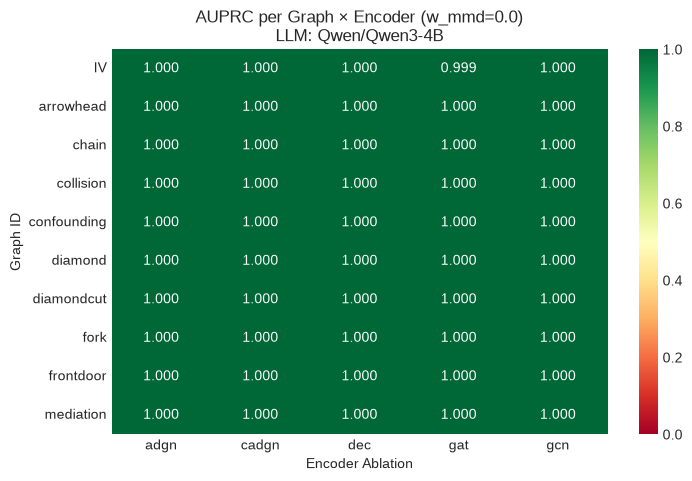

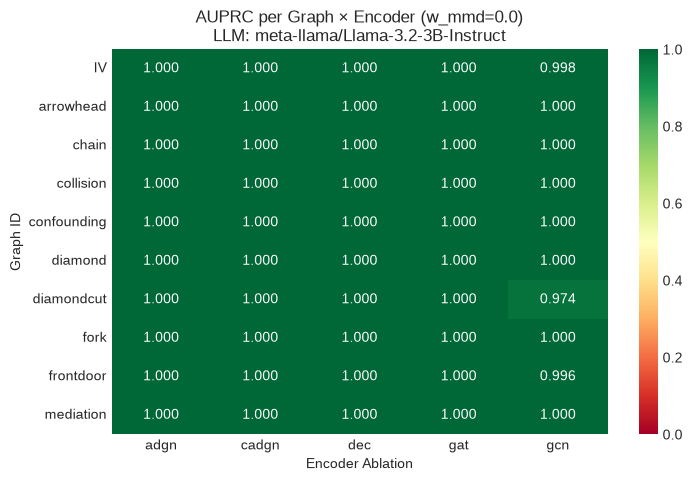

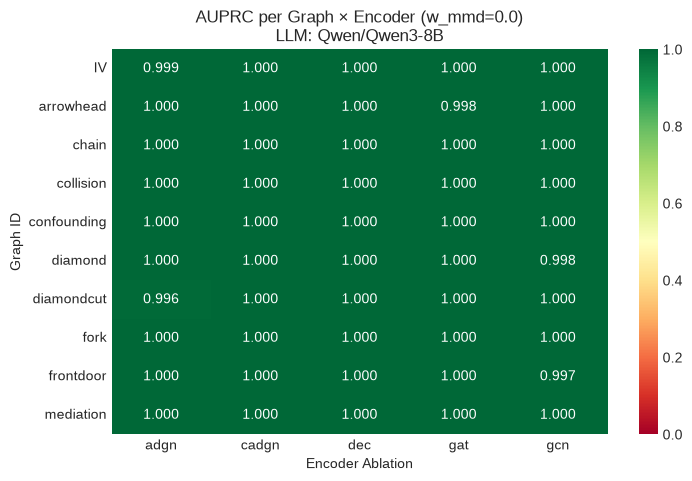

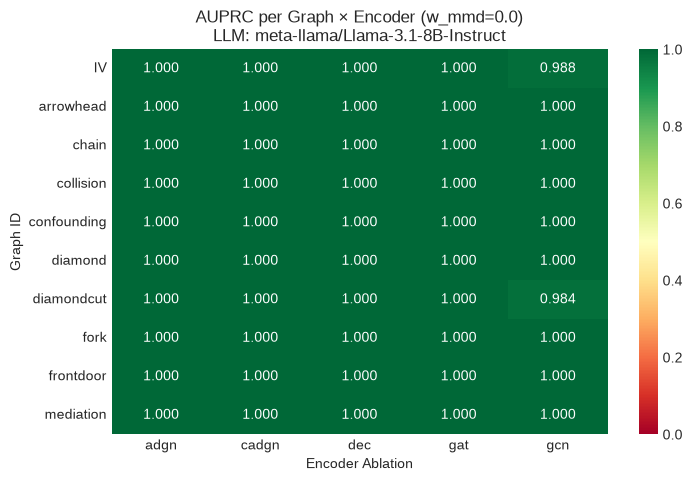

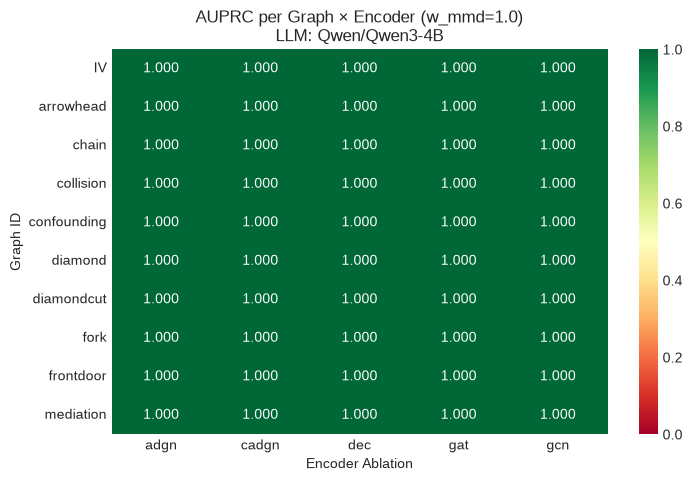

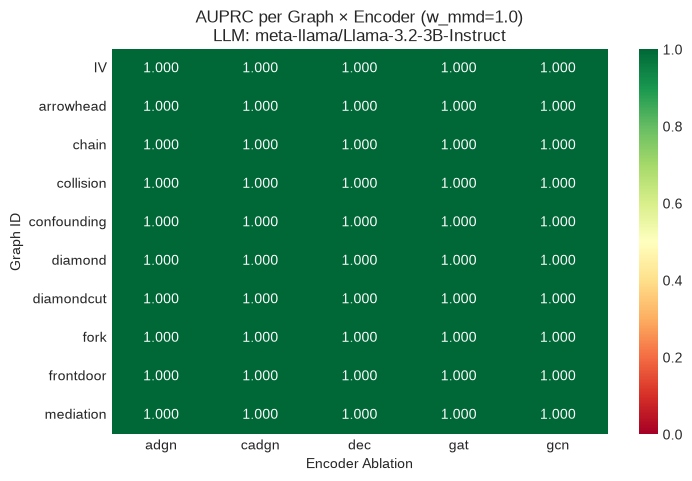

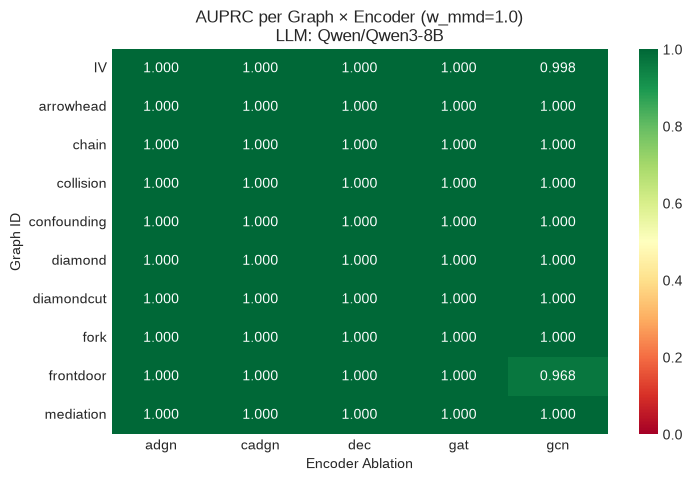

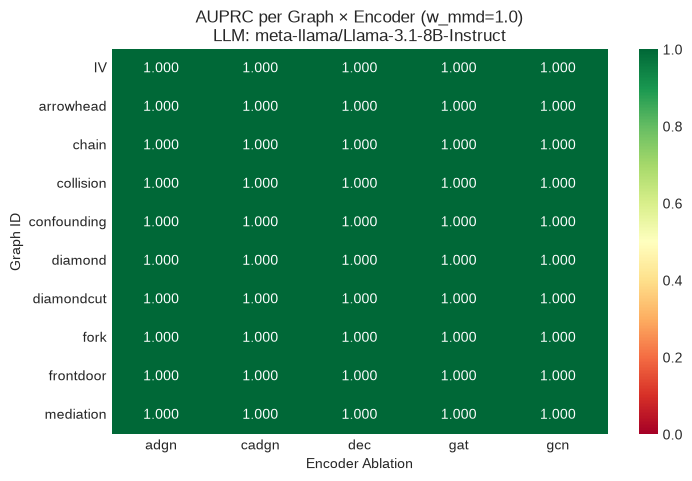

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("seaborn-v0_8-whitegrid")
sp_edges = stage1_output_graph_path / "edges"
sp_edges.mkdir(parents=True, exist_ok=True)

for mi, mmd_val in enumerate(mmd_vals):
    for mj, mdl in enumerate(do_models):
        safename: str = mdl.replace("/", "__")
        pivot = (
            per_graph
            .filter(pl.col("mmd_val") == mmd_val)   # pick one mmd_val for clarity
            .filter(pl.col("llm") == mdl)  # or average across LLMs
            .pivot(values="auprc_mean", index="graph_id", on="ablation")
            .to_pandas()
            .set_index("graph_id")
        )

        fig, ax = plt.subplots(figsize=(8, 5))
        sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn", ax=ax,
                    vmin=0.0, vmax=1.0)
        ax.set_title(f"AUPRC per Graph × Encoder (w_mmd={mmd_val})\nLLM: {mdl}")
        ax.set_xlabel("Encoder Ablation")
        ax.set_ylabel("Graph ID")

        fig.savefig(sp_edges / f"s1_{mmd_val}_{mj}__{safename}_per_graph_heatmap.png")